## Testing Methods in the `QCQATOOLS` Module

This Jupyter Notebook serves as a platform to rigorously test the various methods included in the Python module `QCQATOOLS`.

This module is particularly valuable for researchers performing quality control and quality assessment
of neuroimaging data: detecting the slices that actually contain signal, generating composite PNG
mosaics from single images or recursively from a whole folder, and building interactive HTML pages to
review those images and select the ones that pass or fail the visual inspection.

The tests are organized into the following sections for clarity and ease of navigation:

### Table of Contents

---

* 🔷 1. [`Visual Assessment of the Images`](#qcqa-visual). Methods dedicated to the visual assessment of the images
    * 🔸 1.1. [`get_valid_slices`](#qcqa-get_valid_slices). Get the valid slice indices along each dimension by identifying the regions with signal
    * 🔸 1.2. [`generate_slices`](#qcqa-generate_slices). Generate a composite visualization of brain image slices from a neuroimaging file
    * 🔸 1.3. [`recursively_generate_slices`](#qcqa-recursively_generate_slices). Recursively process the neuroimaging files in a folder to generate PNG visualizations

* 🔷 2. [`Interactive Report Pages`](#qcqa-webpage). Methods dedicated to build interactive HTML pages to review and select the generated images
    * 🔸 2.1. [`generate_image_selection_webpage`](#qcqa-generate_image_selection_webpage). Generate an interactive HTML webpage to display PNG images with selection checkboxes
    * 🔸 2.2. [`create_png_webpage_from_generated_slices`](#qcqa-create_png_webpage_from_generated_slices). Convenience function to create a webpage from the PNG files generated by the slice functions

---

---
## <a id="qcqa-visual"></a>1. Visual Assessment of the Images
Methods dedicated to the visual assessment of the images.

### 1.1 `get_valid_slices`
<a id="qcqa-get_valid_slices"></a>

Get the valid slice indices along each dimension by identifying the regions with signal.

In [1]:
########################### Testing get_valid_slices ###########################
import clabtoolkit.qcqatools as cltqcqa
import clabtoolkit.parcellationtools as cltparc
import nibabel as nib
import numpy as np
import os

print("Test 1: Getting the slices of a synthetic volume where the signal is restricted to a box...")
print("NOTE: The slices are placed at 30%, 50% and 70% of the extent of the signal, not of the whole volume.")
data = np.zeros((100, 100, 100))
data[20:61, 40:81, 10:51] = 1                       # Signal only inside this box
sag_slices, cor_slices, ax_slices = cltqcqa.get_valid_slices(data)
print(f"  Sagittal slices (X) : {sag_slices}   (signal between 20 and 60)")
print(f"  Coronal slices  (Y) : {cor_slices}   (signal between 40 and 80)")
print(f"  Axial slices    (Z) : {ax_slices}   (signal between 10 and 50)")
print("-------------------------------")
print(" ")

print("Test 2: Using a background value different from 0 (ignore_value) and custom slice positions...")
data_bg = np.full((100, 100, 100), -1.0)            # Background = -1
data_bg[20:61, 40:81, 10:51] = 0                    # Signal with value 0
slices = cltqcqa.get_valid_slices(data_bg, ignore_value=-1, slice_positions=[0.25, 0.5, 0.75])
print(f"  Sagittal: {slices[0]}, Coronal: {slices[1]}, Axial: {slices[2]}")
print("-------------------------------")
print(" ")

print("Test 3: Getting the slices of a real image...")
freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:
    os.makedirs("/tmp/qcqa_examples", exist_ok=True)
    image_file = "/tmp/qcqa_examples/simulated_parcellation.nii.gz"
    parc = cltparc.Parcellation.simulate_parcellation(n_regions=10, seed=42)
    parc.save_parcellation(image_file, overwrite=True)
else:
    image_file = os.path.join(freesurfer_home, "subjects", "bert", "mri", "brain.mgz")

img_data = nib.load(image_file).get_fdata()
sag_slices, cor_slices, ax_slices = cltqcqa.get_valid_slices(img_data, slice_positions=[0.4, 0.5, 0.6])
print(f"  Image      : {image_file}")
print(f"  Dimensions : {img_data.shape}")
print(f"  Sagittal: {sag_slices}, Coronal: {cor_slices}, Axial: {ax_slices}")
print("-------------------------------")

Test 1: Getting the slices of a synthetic volume where the signal is restricted to a box...

NOTE: The slices are placed at 30%, 50% and 70% of the extent of the signal, not of the whole volume.

  Sagittal slices (X) : [32, 40, 48]   (signal between 20 and 60)

  Coronal slices  (Y) : [52, 60, 68]   (signal between 40 and 80)

  Axial slices    (Z) : [22, 30, 38]   (signal between 10 and 50)

...

Test 3: Getting the slices of a real image...

  Image      : /opt/freesurfer/subjects/bert/mri/brain.mgz

  Dimensions : (256, 256, 256)

  Sagittal: [114, 127, 140], Coronal: [110, 126, 141], Axial: [94, 113, 131]

-------------------------------

### 1.2 `generate_slices`
<a id="qcqa-generate_slices"></a>

Generate a composite visualization of brain image slices from a neuroimaging file.

Test 1: Generating the default mosaic (3 sagittal, 3 coronal and 3 axial slices) of an image...

NOTE: Always set output_path. Otherwise the PNG is saved next to the input image.

  PNG file: /tmp/qcqa_examples/generate_slices/T1_slices.png

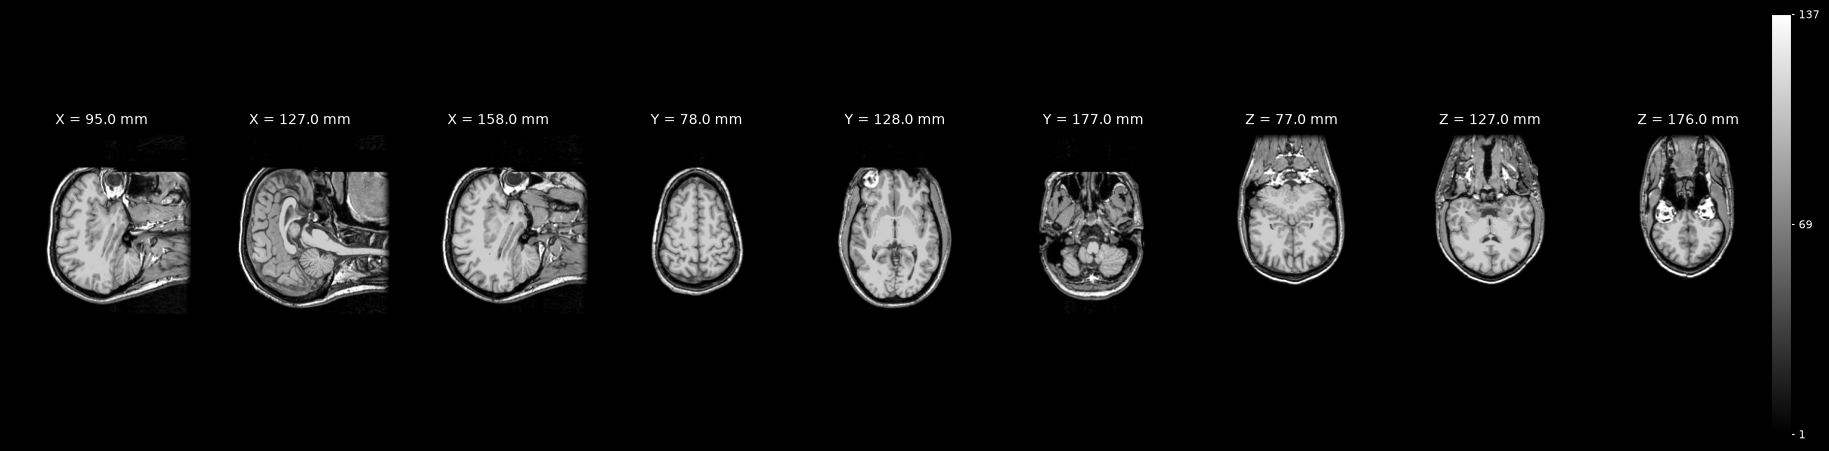

-------------------------------

Test 2: Generating one slice per view of a parcellation with a categorical colormap and no colorbar...

  PNG file: /tmp/qcqa_examples/generate_slices/parcellation_slices.png

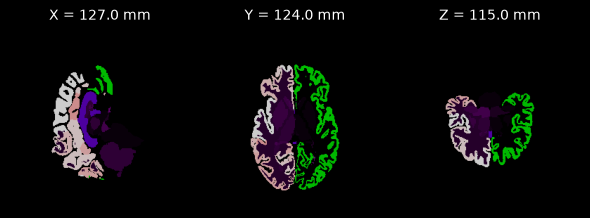

-------------------------------

Test 3: Generating the slices of a 4D image (only the first volume is used) and reusing an existing PNG...

Simulated BIDS dataset created at: /tmp/qcqa_examples/bids_4d
  Subjects: 1 | Sessions/subject: 1 | Modalities: ['func']

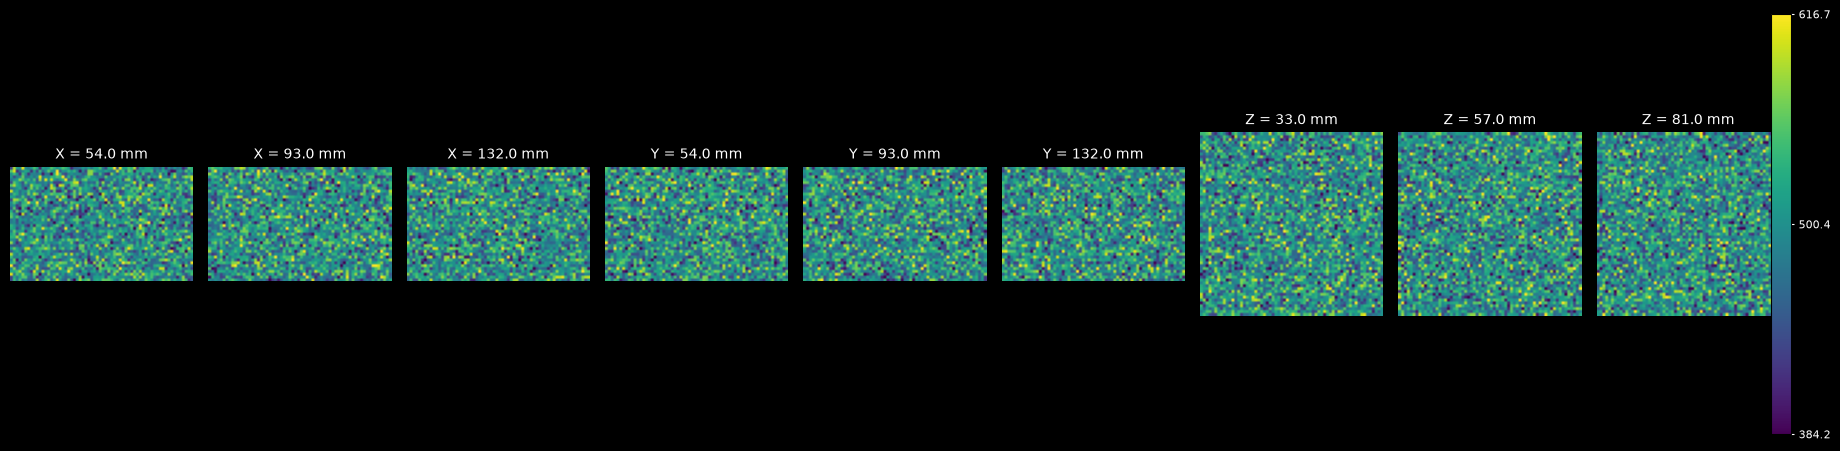

Calling it again with overwrite=False returns the existing PNG without regenerating it:

PNG already exists and overwrite=False: /tmp/qcqa_examples/generate_slices/bold_slices.png

-------------------------------

In [2]:
########################### Testing generate_slices ###########################
import clabtoolkit.qcqatools as cltqcqa
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.bidstools_utils as cltbidsutils
from IPython.display import Image, display
import shutil
import os

out_dir = "/tmp/qcqa_examples/generate_slices"
os.makedirs(out_dir, exist_ok=True)

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:
    parc = cltparc.Parcellation.simulate_parcellation(n_regions=10, seed=42)
    t1_file = parc_file = os.path.join(out_dir, "simulated_parcellation.nii.gz")
    parc.save_parcellation(parc_file, overwrite=True)
else:
    mri_dir = os.path.join(freesurfer_home, "subjects", "bert", "mri")
    t1_file = os.path.join(mri_dir, "T1.mgz")
    parc_file = os.path.join(mri_dir, "aparc+aseg.mgz")

print("Test 1: Generating the default mosaic (3 sagittal, 3 coronal and 3 axial slices) of an image...")
print("NOTE: Always set output_path. Otherwise the PNG is saved next to the input image.")
png_file = cltqcqa.generate_slices(
    t1_file, output_path=os.path.join(out_dir, "T1_slices.png"), dpi=100, overwrite=True
)
print(f"  PNG file: {png_file}")
display(Image(filename=png_file, width=1000))
print("-------------------------------")
print(" ")

print("Test 2: Generating one slice per view of a parcellation with a categorical colormap and no colorbar...")
png_file = cltqcqa.generate_slices(
    parc_file,
    output_path=os.path.join(out_dir, "parcellation_slices.png"),
    slice_positions=[0.5],
    cmap="nipy_spectral",
    intensity_percentiles=(0, 100),
    show_colorbar=False,
    dpi=100,
    overwrite=True,
)
print(f"  PNG file: {png_file}")
display(Image(filename=png_file, width=500))
print("-------------------------------")
print(" ")

print("Test 3: Generating the slices of a 4D image (only the first volume is used) and reusing an existing PNG...")
bids_dir = "/tmp/qcqa_examples/bids_4d"
shutil.rmtree(bids_dir, ignore_errors=True)
cltbidsutils.create_a_simulated_bids_dataset(bids_dir, n_subjects=1, modalities=("func",), show_progress=False)
bold_file = os.path.join(bids_dir, "sub-01", "func", "sub-01_task-rest_bold.nii.gz")
bold_png = os.path.join(out_dir, "bold_slices.png")
png_file = cltqcqa.generate_slices(bold_file, output_path=bold_png, cmap="viridis", dpi=100, overwrite=True)
display(Image(filename=png_file, width=1000))
print("Calling it again with overwrite=False returns the existing PNG without regenerating it:")
png_file = cltqcqa.generate_slices(bold_file, output_path=bold_png, overwrite=False)
print("-------------------------------")

### 1.3 `recursively_generate_slices`
<a id="qcqa-recursively_generate_slices"></a>

Recursively process the neuroimaging files in a folder to generate PNG visualizations.

Simulated BIDS dataset created at: /tmp/qcqa_examples/bids_recursive
  Subjects: 2 | Sessions/subject: 1 | Modalities: ['anat', 'func']

Test 1: Generating the PNGs of all the images of the dataset in a separate output folder...

NOTE: The folder structure of the dataset is preserved inside the output folder.

Output()

  sub-01/anat/sub-01_T1w.png

  sub-01/func/sub-01_task-rest_bold.png

  sub-02/anat/sub-02_T1w.png

  sub-02/func/sub-02_task-rest_bold.png

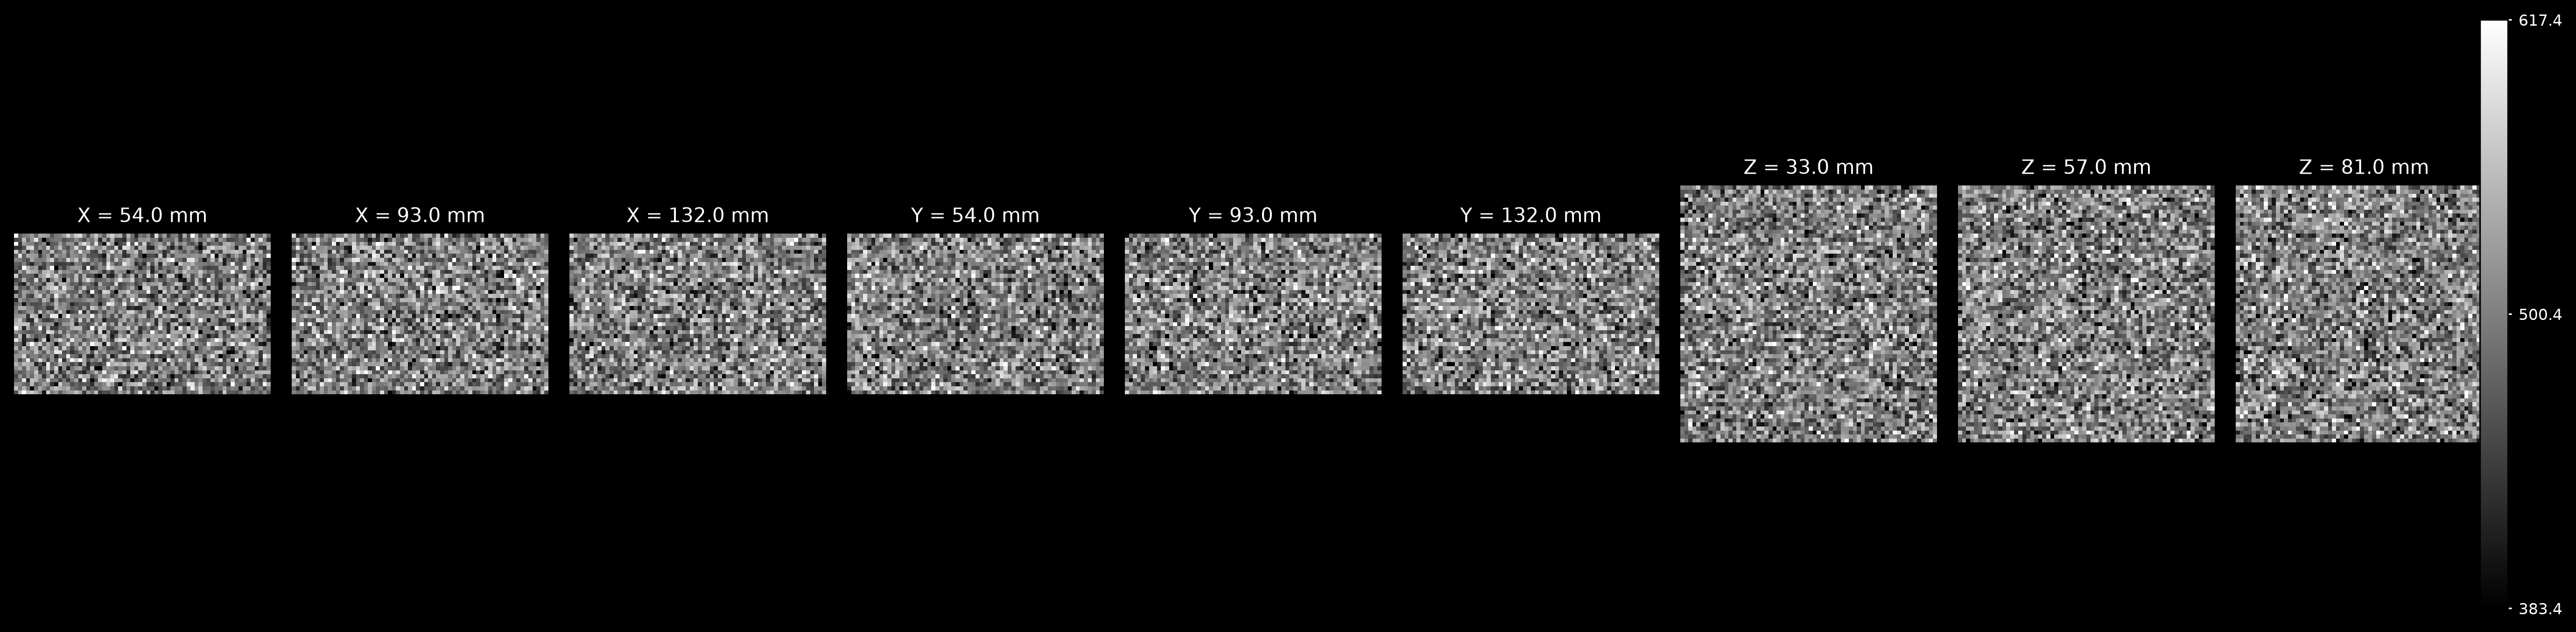

-------------------------------

Test 2: Generating the PNGs of the T1w images only, next to the images and using 2 parallel jobs...

Output()

  sub-01/anat/sub-01_T1w.png

  sub-02/anat/sub-02_T1w.png

...

PNG already exists and overwrite=False: /tmp/qcqa_examples/qc_figures/sub-02/anat/sub-02_T1w.png

PNG already exists and overwrite=False: /tmp/qcqa_examples/qc_figures/sub-01/func/sub-01_task-rest_bold.png

PNG already exists and overwrite=False: /tmp/qcqa_examples/qc_figures/sub-01/anat/sub-01_T1w.png

  Number of PNG files returned: 4

-------------------------------

In [3]:
########################### Testing recursively_generate_slices ###########################
import clabtoolkit.qcqatools as cltqcqa
import clabtoolkit.bidstools_utils as cltbidsutils
from IPython.display import Image, display
import shutil
import os

# Simulated BIDS dataset with 2 subjects and anatomical (3D) and functional (4D) images
bids_dir = "/tmp/qcqa_examples/bids_recursive"
qc_dir = "/tmp/qcqa_examples/qc_figures"
shutil.rmtree(bids_dir, ignore_errors=True)
shutil.rmtree(qc_dir, ignore_errors=True)
cltbidsutils.create_a_simulated_bids_dataset(
    bids_dir, n_subjects=2, modalities=("anat", "func"), show_progress=False
)

print("Test 1: Generating the PNGs of all the images of the dataset in a separate output folder...")
print("NOTE: The folder structure of the dataset is preserved inside the output folder.")
png_files = cltqcqa.recursively_generate_slices(bids_dir, output_folder=qc_dir, verbose=False)
for png in sorted(png_files):
    print(f"  {os.path.relpath(png, qc_dir)}")
display(Image(filename=sorted(png_files)[0], width=1000))
print("-------------------------------")
print(" ")

print("Test 2: Generating the PNGs of the T1w images only, next to the images and using 2 parallel jobs...")
png_files = cltqcqa.recursively_generate_slices(bids_dir, and_filter="T1w", n_jobs=2, verbose=False)
for png in sorted(png_files):
    print(f"  {os.path.relpath(png, bids_dir)}")
print("-------------------------------")
print(" ")

print("Test 3: Running it again with overwrite=False (the existing PNGs are skipped)...")
png_files = cltqcqa.recursively_generate_slices(bids_dir, output_folder=qc_dir, overwrite=False, verbose=False)
print(f"  Number of PNG files returned: {len(png_files)}")
print("-------------------------------")

---
## <a id="qcqa-webpage"></a>2. Interactive Report Pages
Methods dedicated to build interactive HTML pages to review and select the generated images.

### 2.1 `generate_image_selection_webpage`
<a id="qcqa-generate_image_selection_webpage"></a>

Generate an interactive HTML webpage to display PNG images with selection checkboxes.

In [4]:
########################### Testing generate_image_selection_webpage ###########################
import clabtoolkit.qcqatools as cltqcqa
import clabtoolkit.bidstools_utils as cltbidsutils
import shutil
import json
import glob
import re
import os

# Simulated BIDS dataset and PNGs generated next to each image
bids_dir = "/tmp/qcqa_examples/bids_webpage"
shutil.rmtree(bids_dir, ignore_errors=True)
cltbidsutils.create_a_simulated_bids_dataset(
    bids_dir, n_subjects=2, modalities=("anat", "func"), show_progress=False
)

# Adding a SeriesDescription to the JSON sidecars. It is shown under each image in the webpage
for json_file in glob.glob(os.path.join(bids_dir, "sub-*", "*", "*.json")):
    with open(json_file) as f:
        sidecar = json.load(f)
    sidecar["SeriesDescription"] = os.path.basename(json_file).replace(".json", "").split("_")[-1]
    with open(json_file, "w") as f:
        json.dump(sidecar, f, indent=4)

cltqcqa.recursively_generate_slices(bids_dir, verbose=False)

print("Test 1: Creating the selection webpage with the default settings...")
print("NOTE: The page is saved as png_selection.html inside the root directory.")
html_file = cltqcqa.generate_image_selection_webpage(bids_dir)
html = open(html_file).read()
n_images = html.count('type="checkbox"')
descriptions = re.findall(r"📝 (\w+)", html)
first_value = re.findall(r'value="([^"]+)"', html)[0]
print(f"  Images (checkboxes) : {n_images}")
print(f"  Descriptions        : {descriptions}")
print(f"  Checkbox values     : the original NIfTI files, e.g. {first_value}")
print("-------------------------------")
print(" ")

print("Test 2: Creating a webpage with a custom title, image width and output file...")
html_file = cltqcqa.generate_image_selection_webpage(
    bids_dir,
    output_html=os.path.join(bids_dir, "qc_review.html"),
    title="Quality Control - Simulated Dataset",
    image_width="900px",
    overwrite=True,
)
html = open(html_file).read()
title = re.search(r"<title>(.*)</title>", html).group(1)
width = re.search(r"width: (\d+px)", html).group(1)
print(f"  Title       : {title}")
print(f"  Image width : {width}")
print("-------------------------------")
print(" ")

print("Test 3: Calling it again with overwrite=False (the existing webpage is returned)...")
html_file = cltqcqa.generate_image_selection_webpage(bids_dir, output_html=html_file, overwrite=False)
print(f"  HTML file: {html_file}")
print("Open the HTML file in a web browser to review the images and download the list of selected files.")
print("-------------------------------")

Simulated BIDS dataset created at: /tmp/qcqa_examples/bids_webpage
  Subjects: 2 | Sessions/subject: 1 | Modalities: ['anat', 'func']

Output()

Test 1: Creating the selection webpage with the default settings...

NOTE: The page is saved as png_selection.html inside the root directory.

Found 4 PNG files

...

Test 3: Calling it again with overwrite=False (the existing webpage is returned)...

HTML file already exists and overwrite=False: /tmp/qcqa_examples/bids_webpage/qc_review.html

  HTML file: /tmp/qcqa_examples/bids_webpage/qc_review.html

Open the HTML file in a web browser to review the images and download the list of selected files.

-------------------------------

### 2.2 `create_png_webpage_from_generated_slices`
<a id="qcqa-create_png_webpage_from_generated_slices"></a>

Convenience function to create a webpage from the PNG files generated by the slice functions.

In [5]:
########################### Testing create_png_webpage_from_generated_slices ###########################
import clabtoolkit.qcqatools as cltqcqa
import clabtoolkit.bidstools_utils as cltbidsutils
import shutil
import re
import os

# Simulated BIDS dataset
bids_dir = "/tmp/qcqa_examples/bids_slices_webpage"
qc_dir = "/tmp/qcqa_examples/qc_slices_webpage"
shutil.rmtree(bids_dir, ignore_errors=True)
shutil.rmtree(qc_dir, ignore_errors=True)
cltbidsutils.create_a_simulated_bids_dataset(
    bids_dir, n_subjects=3, modalities=("anat",), show_progress=False
)

print("Test 1: Generating the slices of the dataset and creating the selection webpage in one go...")
png_files = cltqcqa.recursively_generate_slices(bids_dir, output_folder=qc_dir, verbose=False)
html_file = cltqcqa.create_png_webpage_from_generated_slices(qc_dir)
html = open(html_file).read()
title = re.search(r"<title>(.*)</title>", html).group(1)
n_images = html.count('type="checkbox"')
print(f"  Title  : {title}")
print(f"  Images : {n_images}")
print("-------------------------------")
print(" ")

print("Test 2: Saving the webpage in a custom location and overwriting it...")
html_file = cltqcqa.create_png_webpage_from_generated_slices(
    qc_dir, output_html=os.path.join(qc_dir, "brain_slices_review.html"), overwrite=True
)
print(f"  HTML file: {html_file}")
print("-------------------------------")

Simulated BIDS dataset created at: /tmp/qcqa_examples/bids_slices_webpage
  Subjects: 3 | Sessions/subject: 1 | Modalities: ['anat']

Test 1: Generating the slices of the dataset and creating the selection webpage in one go...

Output()

Found 3 PNG files

Output()

...

Found 3 PNG files

Output()

HTML file saved: /tmp/qcqa_examples/qc_slices_webpage/brain_slices_review.html

  HTML file: /tmp/qcqa_examples/qc_slices_webpage/brain_slices_review.html

-------------------------------